# UK Road Safety — Cleaning & EDA

**Author:** Leomary Rodriguez
**Project:** Phase 2 Portfolio Project — Mapping and Modeling UK Road Safety

There are two files, joined by `Accident_Index`:

- **Accident_Information.csv** — one row per accident
- **Vehicle_Information.csv** — one row per vehicle. An accident with 2 cars has 2 rows here.

I clean the data first, then explore it. The question I am mainly trying to answer is:
**what makes an accident more likely to be fatal?** That is what our model will try to predict
later, so I want to understand it first.

I ended up with 7 main findings. They are listed at the end in Section 12.

Both files have about 2 million rows, so some cells take a minute or two to run.

**Getting the data:** the raw CSVs are too big for GitHub, so they are not stored in the repo.
Download them from [Kaggle](https://www.kaggle.com/datasets/tsiaras/uk-road-safety-accidents-and-vehicles/data)
and put both files in `data/raw/`, then run the cells in order. See
[`data/README.md`](../../data/README.md) for more detail.

## Section 0 — Import the libraries we need

Run this first, every time you open the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Section 1 — Load the data

In [2]:
accidents = pd.read_csv('../../data/raw/Accident_Information.csv', low_memory=False)
accidents.shape

(2047256, 34)

The vehicle file is not saved as UTF-8, so reading it the normal way gives a
`UnicodeDecodeError`. Adding `encoding='cp1252'` tells pandas which character set the file
actually uses.

`low_memory=False` makes pandas read each column in one go. Without it pandas reads the file
in chunks, and it can guess a different data type for different parts of the same column.

In [3]:
vehicles = pd.read_csv('../../data/raw/Vehicle_Information.csv', low_memory=False, encoding='cp1252')
vehicles.shape

(2177205, 24)

The accident file has 2,047,256 rows and the vehicle file has 2,177,205.

The vehicle file is bigger because it has one row per vehicle, and most accidents involve more
than one vehicle. That is the main thing to remember about these two files — they count
different things, so I can't compare them directly until I join them.

## Section 2 — First look at the data

Before changing anything, just look: what columns are there, what do the values look like,
what type did pandas guess for each column.

In [4]:
accidents.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [5]:
accidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 2047256 entries, 0 to 2047255
Data columns (total 34 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Accident_Index                               str    
 1   1st_Road_Class                               str    
 2   1st_Road_Number                              float64
 3   2nd_Road_Class                               str    
 4   2nd_Road_Number                              float64
 5   Accident_Severity                            str    
 6   Carriageway_Hazards                          str    
 7   Date                                         str    
 8   Day_of_Week                                  str    
 9   Did_Police_Officer_Attend_Scene_of_Accident  float64
 10  Junction_Control                             str    
 11  Junction_Detail                              str    
 12  Latitude                                     float64
 13  Light_Conditions       

In [6]:
vehicles.head()

,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,...,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
0,200401BS00001,26 - 35,3.0,Urban area,4.0,1588.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
1,200401BS00002,26 - 35,NaN,Urban area,3.0,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,109,Data missing or out of range,Front,2004
2,200401BS00003,26 - 35,4.0,Data missing or out of range,NaN,998.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Turning right,1,109,Data missing or out of range,Front,2004
3,200401BS00003,66 - 75,NaN,Data missing or out of range,NaN,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
4,200401BS00004,26 - 35,1.0,Urban area,4.0,124.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Motorcycle 125cc and under,Data missing or out of range,Front,2004


In [7]:
vehicles.info()

<class 'pandas.DataFrame'>
RangeIndex: 2177205 entries, 0 to 2177204
Data columns (total 24 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Accident_Index                    str    
 1   Age_Band_of_Driver                str    
 2   Age_of_Vehicle                    float64
 3   Driver_Home_Area_Type             str    
 4   Driver_IMD_Decile                 float64
 5   Engine_Capacity_.CC.              float64
 6   Hit_Object_in_Carriageway         str    
 7   Hit_Object_off_Carriageway        str    
 8   Journey_Purpose_of_Driver         str    
 9   Junction_Location                 str    
 10  make                              str    
 11  model                             str    
 12  Propulsion_Code                   str    
 13  Sex_of_Driver                     str    
 14  Skidding_and_Overturning          str    
 15  Towing_and_Articulation           str    
 16  Vehicle_Leaving_Carriageway       str    
 17  

In [8]:
print('Accident file years:', accidents['Year'].min(), 'to', accidents['Year'].max())
print('Vehicle file years: ', vehicles['Year'].min(), 'to', vehicles['Year'].max())

Accident file years: 2005 to 2017
Vehicle file years:  2004 to 2016


**The two year ranges do not match.** Accidents cover 2005–2017 but vehicles cover 2004–2016.

So the vehicle file has a year the accident file doesn't have (2004), and the accident file
has a year the vehicle file doesn't have (2017).

This matters because when I join the two files later, rows from a year the other file doesn't
cover have nothing to match to, so they get dropped. I check exactly how many in Section 5
instead of assuming it is a small number.

## Section 3 — Find the missing values

`.isnull()` counts blank cells. `.sum()` then adds up the `True` values per column, so I get
one number per column telling me how many blanks it has.

In [9]:
accidents.isnull().sum()

Accident_Index                                       0
1st_Road_Class                                       0
1st_Road_Number                                      2
2nd_Road_Class                                  844272
2nd_Road_Number                                  17593
Accident_Severity                                    0
Carriageway_Hazards                            2007807
Date                                                 0
Day_of_Week                                          0
Did_Police_Officer_Attend_Scene_of_Accident        278
Junction_Control                                     0
Junction_Detail                                      0
Latitude                                           174
Light_Conditions                                     0
Local_Authority_(District)                           0
Local_Authority_(Highway)                            0
Location_Easting_OSGR                              164
Location_Northing_OSGR                             164
Longitude 

In [10]:
vehicles.isnull().sum()

Accident_Index                            0
Age_Band_of_Driver                        0
Age_of_Vehicle                       358149
Driver_Home_Area_Type                     0
Driver_IMD_Decile                    734812
Engine_Capacity_.CC.                 265861
Hit_Object_in_Carriageway           2087824
Hit_Object_off_Carriageway          1989741
Journey_Purpose_of_Driver                 0
Junction_Location                         0
make                                 110845
model                                325331
Propulsion_Code                      245843
Sex_of_Driver                             0
Skidding_and_Overturning            1898208
Towing_and_Articulation                   0
Vehicle_Leaving_Carriageway               0
Vehicle_Location.Restricted_Lane       1317
Vehicle_Manoeuvre                         0
Vehicle_Reference                         0
Vehicle_Type                              0
Was_Vehicle_Left_Hand_Drive               0
X1st_Point_of_Impact            

Two columns are nearly all blank: `Carriageway_Hazards` (2,007,807 missing) and
`Special_Conditions_at_Site` (1,995,137 missing), which is about 98% of rows.

**But these are not really missing.** A blank here means there was no hazard and no special
condition on the road, which is the normal situation. If I dropped these columns for being
empty I would be throwing away real information. They should be filled with `'None'` later.

`Driver_IMD_Decile` and `Age_of_Vehicle` are different — those really were not recorded.

### Finding 1: a lot of the missing data is hidden as text

`.isnull()` only finds truly blank cells. But this dataset also writes missing values as
ordinary words, like `'Data missing or out of range'` or `'Not known'`. Pandas reads those as
normal text, so they don't count as missing at all.

If I don't fix this, those words become their own category and end up in my charts and in the
model as though they were real answers.

`.value_counts()` lists every different value in a column with how many times it appears,
which is how I find them.

In [11]:
accidents['Junction_Control'].value_counts()

Junction_Control
Give way or uncontrolled               988313
Data missing or out of range           754311
Auto traffic signal                    211335
Not at junction or within 20 metres     77304
Stop sign                               12333
Authorised person                        3660
Name: count, dtype: int64

In [12]:
accidents['Weather_Conditions'].value_counts()

Weather_Conditions
Fine no high winds              1640095
Raining no high winds            239281
Other                             44083
Unknown                           42521
Raining + high winds              28343
Fine + high winds                 25816
Snowing no high winds             13387
Fog or mist                       11068
Snowing + high winds               2487
Data missing or out of range        175
Name: count, dtype: int64

In [13]:
accidents['Road_Type'].value_counts()

Road_Type
Single carriageway              1527882
Dual carriageway                 303407
Roundabout                       136754
One way street                    43258
Slip road                         21558
Unknown                           14396
Data missing or out of range          1
Name: count, dtype: int64

In [14]:
vehicles['Journey_Purpose_of_Driver'].value_counts()

Journey_Purpose_of_Driver
Not known                       834626
Other/Not known (2005-10)       555726
Journey as part of work         391713
Commuting to/from work          202525
Data missing or out of range    133560
Other                            32965
Taking pupil to/from school      21792
Pupil riding to/from school       4298
Name: count, dtype: int64

In [15]:
vehicles['Age_Band_of_Driver'].value_counts()

Age_Band_of_Driver
26 - 35                         450531
36 - 45                         435686
46 - 55                         348762
21 - 25                         238765
56 - 65                         206181
16 - 20                         175874
Data missing or out of range    171052
66 - 75                          91454
Over 75                          54236
11 - 15                           3655
6 - 10                             884
0 - 5                              125
Name: count, dtype: int64

In [16]:
vehicles['Sex_of_Driver'].value_counts()

Sex_of_Driver
Male                            1468081
Female                           633005
Not known                         76051
Data missing or out of range         68
Name: count, dtype: int64

There is a lot of missing data hiding as text:

- `Journey_Purpose_of_Driver` — 834,626 rows say `'Not known'` and 133,560 more say
  `'Data missing or out of range'`, so about 45% of the file
- `Junction_Control` — 754,311 rows, about 37%
- `Driver_Home_Area_Type` — 334,344 rows
- `Age_Band_of_Driver` — 171,052 rows
- `Sex_of_Driver` — 76,051 say `'Not known'`
- `Weather_Conditions` — 42,521 say `'Unknown'`
- `Road_Type` — 14,396 say `'Unknown'`

The first two are the worrying ones, because more than a third of their values are missing.
I would be careful about using either in a model.

One thing I checked before cleaning: `Light_Conditions` has a value called
`'Darkness - lighting unknown'`. That is a **real** answer — the road was dark and nobody
recorded whether the lights were on. It is spelled differently from plain `'Unknown'`, so my
cleaning won't touch it. I check that below.

## Section 4 — Clean the data

Now I replace those words with `np.nan`, which is what pandas uses for a real blank. Once they
are `np.nan`, pandas leaves them out of counts and charts automatically.

The same four words appear in lots of different columns, so rather than writing one line per
column I run `.replace()` on the whole table at once.

In [17]:
accidents = accidents.replace('Data missing or out of range', np.nan)
accidents = accidents.replace('Unknown', np.nan)
accidents = accidents.replace('Not known', np.nan)
accidents = accidents.replace('NA', np.nan)

In [18]:
vehicles = vehicles.replace('Data missing or out of range', np.nan)
vehicles = vehicles.replace('Unknown', np.nan)
vehicles = vehicles.replace('Not known', np.nan)
vehicles = vehicles.replace('NA', np.nan)

Check that it worked, and that the real `'Darkness - lighting unknown'` value survived.

In [19]:
print('Weather Unknown left over:', (accidents['Weather_Conditions'] == 'Unknown').sum())
print('Junction_Control missing now:', accidents['Junction_Control'].isnull().sum())
print('Darkness - lighting unknown kept:', (accidents['Light_Conditions'] == 'Darkness - lighting unknown').sum())

Weather Unknown left over: 0
Junction_Control missing now: 754311
Darkness - lighting unknown kept: 24362


Both checks came out how I wanted:

- `'Unknown'` in the weather column is now 0, so the placeholders were replaced.
- `'Darkness - lighting unknown'` still has all 24,362 rows, so I didn't delete a real category
  by accident.

The second line is the important one — it proves the replacement only hit the fake values.

The `Date` and `Time` columns are stored as text. `pd.to_datetime` turns them into real dates,
and `.dt.month` / `.dt.hour` then pull out just the part I want as a new column. I need those
for the time charts later.

In [20]:
accidents['Date'] = pd.to_datetime(accidents['Date'], format='%Y-%m-%d')
accidents['Month'] = accidents['Date'].dt.month
accidents['Hour'] = pd.to_datetime(accidents['Time'], format='%H:%M', errors='coerce').dt.hour

In [21]:
print('Date range:', accidents['Date'].min(), 'to', accidents['Date'].max())
print('Rows where Time could not be read:', accidents['Hour'].isnull().sum())

Date range: 2005-01-01 00:00:00 to 2017-12-31 00:00:00
Rows where Time could not be read: 156


All 2,047,256 dates converted fine. Only 156 rows have a `Time` I couldn't read, which is
0.008% of the file, so I am ignoring them.

`errors='coerce'` means "if you can't read a value, put a blank there instead of stopping".
Without it, those 156 bad rows would crash the whole cell.

### Finding 2: some values are wrong rather than missing

Checking for blanks only finds empty cells. Some columns have values that are definitely
there but impossible, and `describe()` shows those because it prints the smallest and largest
value in the column.

In [22]:
vehicles['Age_of_Vehicle'].describe()

count    1.819056e+06
mean     7.108167e+00
std      4.725886e+00
min      1.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      1.110000e+02
Name: Age_of_Vehicle, dtype: float64

In [23]:
vehicles['Engine_Capacity_.CC.'].describe()

count    1.911344e+06
mean     2.042234e+03
std      1.950143e+03
min      1.000000e+00
25%      1.299000e+03
50%      1.598000e+03
75%      1.997000e+03
max      9.600000e+04
Name: Engine_Capacity_.CC., dtype: float64

In [24]:
vehicles['Vehicle_Type'].value_counts().head(8)

Vehicle_Type
Car                                     1528628
Van / Goods 3.5 tonnes mgw or under      117427
109                                       82920
Bus or coach (17 or more pass seats)      76757
Motorcycle over 500cc                     71472
Motorcycle 125cc and under                61600
Goods 7.5 tonnes mgw and over             55426
Taxi/Private hire car                     43781
Name: count, dtype: int64

Three problems that checking for blanks would never have found:

1. `Age_of_Vehicle` goes up to **111 years**, when the middle value is 7. There are some
   genuine classic cars, but 111 is almost certainly a typing mistake.
2. `Engine_Capacity_.CC.` goes up to **96,000cc**, when the middle value is 1,598. That would
   be a 96 litre engine, which doesn't exist in a road car.
3. `Vehicle_Type` mostly has readable labels like `'Car'`, but 82,920 rows just say **`109`**.
   That is a code that never got turned into a label, and no lookup table comes with the files.

None of these stop the EDA, but all three need fixing before we model.

## Section 5 — Quick sanity checks

In [25]:
# how many fully duplicated rows are there?
print('Duplicate rows in accidents:', accidents.duplicated().sum())
print('Duplicate rows in vehicles: ', vehicles.duplicated().sum())

Duplicate rows in accidents: 0
Duplicate rows in vehicles:  0


In [26]:
# Accident_Index should be unique in the accident file (one row per accident) — this should print 0
accidents['Accident_Index'].duplicated().sum()

np.int64(0)

In [27]:
# how many vehicle rows have a matching accident in the accident file?
has_match = vehicles['Accident_Index'].isin(accidents['Accident_Index'])
has_match.value_counts()

Accident_Index
True     2058408
False     118797
Name: count, dtype: int64

In [28]:
# which years are the non-matching vehicle rows from?
vehicles[has_match == False]['Year'].value_counts()

Year
2004    118797
Name: count, dtype: int64

No duplicate rows in either file, and `Accident_Index` is unique across all 2,047,256 accident
rows, so the accident file really is one row per accident.

For the join: 2,058,408 vehicle rows find a matching accident and 118,797 do not, so 94.5%
match.

The last cell is the useful one. **Every single one of the 118,797 failures is from 2004** —
exactly the year I spotted missing in Section 2. So the join isn't losing random broken rows,
it is losing one year I already knew about. That means I can use it without worrying.

## Section 6 — Save the cleaned data

So next time I don't have to redo Sections 3-4. The later notebooks in the project can read
these files instead of the raw ones.

In [29]:
accidents.to_csv('../../data/processed/accidents_clean.csv', index=False)
vehicles.to_csv('../../data/processed/vehicles_clean.csv', index=False)

---
# EDA

Everything above was cleaning. From here on I am exploring.

If you're coming back to this later, you can skip straight here after running:
```python
accidents = pd.read_csv('../../data/processed/accidents_clean.csv', low_memory=False)
vehicles = pd.read_csv('../../data/processed/vehicles_clean.csv', low_memory=False)
```

## Section 7 — One column at a time

The pattern I use over and over: `.value_counts()` counts how many times each value appears,
then `.plot(kind='bar')` draws those counts. `.reindex()` puts the bars in an order I choose
rather than largest-first.

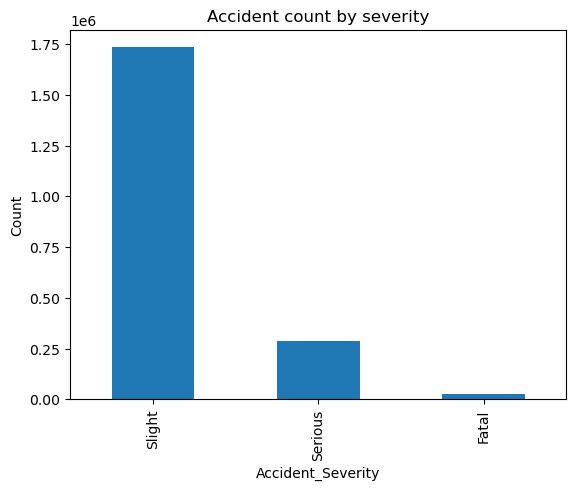

In [30]:
severity_order = ['Slight', 'Serious', 'Fatal']

accidents['Accident_Severity'].value_counts().reindex(severity_order).plot(kind='bar')
plt.title('Accident count by severity')
plt.ylabel('Count')
plt.show()

In [31]:
accidents['Accident_Severity'].value_counts(normalize=True) * 100

Accident_Severity
Slight     84.725506
Serious    13.986478
Fatal       1.288017
Name: proportion, dtype: float64

### Finding 3: only 1.29% of accidents are fatal

- Slight — 1,734,548 accidents (84.73%)
- Serious — 286,339 accidents (13.99%)
- Fatal — 26,369 accidents (**1.29%**)

This causes a real problem for the model we build in Part 2.

Imagine a model that ignores everything and just answers `'Slight'` every time. Because 84.7%
of accidents really are Slight, that model would be **84.7% accurate** — which sounds good. But
it would never once spot a fatal crash, which is the thing we actually care about.

So two things follow:

- **Accuracy is the wrong score here.** We should use precision and recall, which look at how
  well the model does on the rare classes.
- **We need to handle the imbalance**, either by telling the model fatal crashes matter more,
  or by changing how many of each class it trains on.

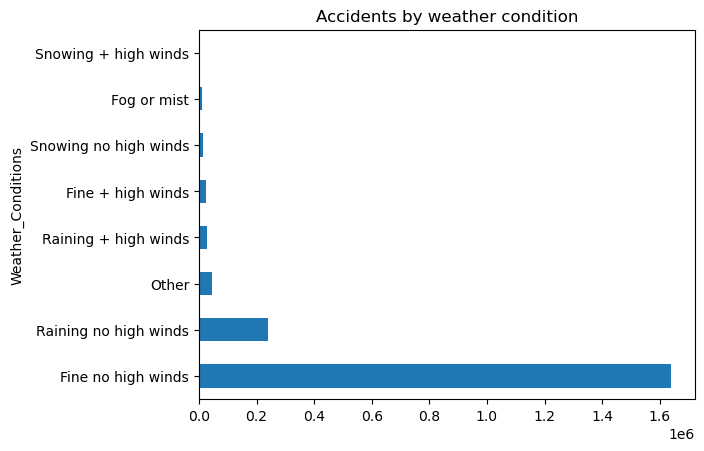

In [32]:
accidents['Weather_Conditions'].value_counts().plot(kind='barh')
plt.title('Accidents by weather condition')
plt.show()

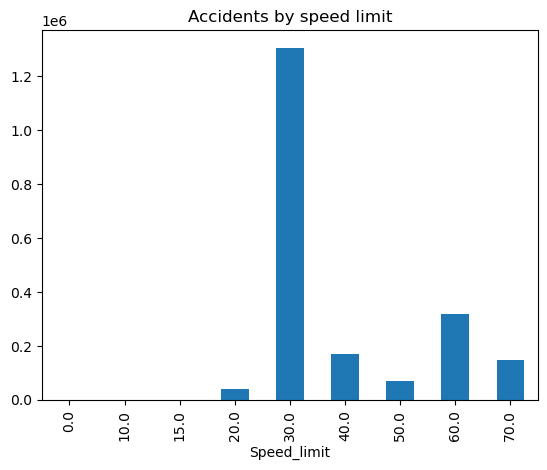

In [33]:
accidents['Speed_limit'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents by speed limit')
plt.show()

### Finding 4: counts show where people drive, not what is dangerous

Both charts above show the same thing:

- 80% of accidents happened in fine weather with no high wind
- 64% of them were at a 30 mph speed limit

Looking at the weather chart it would be easy to say "fine weather is dangerous". But that is
backwards. Most driving in the UK happens in fine weather on ordinary 30 mph roads — so most
crashes happen there too, simply because there are far more chances for something to go wrong.

**This is the idea the rest of the notebook is built on.** Counting accidents only tells me
where people drive. To find what is actually dangerous I need the *percentage* of accidents in
each group that were fatal, which is what Section 10 does.

## Section 8 — What time of day accidents happen

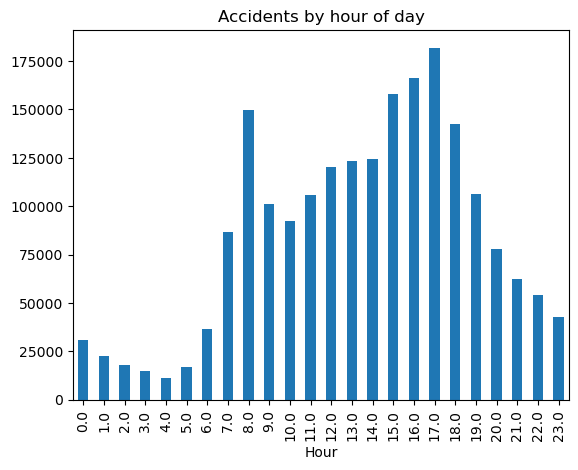

In [34]:
accidents['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents by hour of day')
plt.show()

There are two peaks, and they match commuting times: one at 08:00 (149,480 accidents) and a
bigger one at 17:00 (181,881). The quietest hour is 04:00 with only 11,400.

The evening peak is more spread out, roughly 15:00 to 18:00. I think that is because school
runs and people finishing work happen at different times, while the morning rush is squeezed
into a shorter window.

Same warning as Finding 4 — these are counts, so they mostly show when people are on the road.
I have no traffic volume data, so I can't tell whether 17:00 is genuinely more dangerous or
just busier.

## Section 9 — Where accidents happen

Two million dots is far too many to draw, so `.sample(20000)` picks a random 20,000 of them.
`random_state=42` fixes which ones get picked, so the chart looks the same every time instead
of changing on each run.

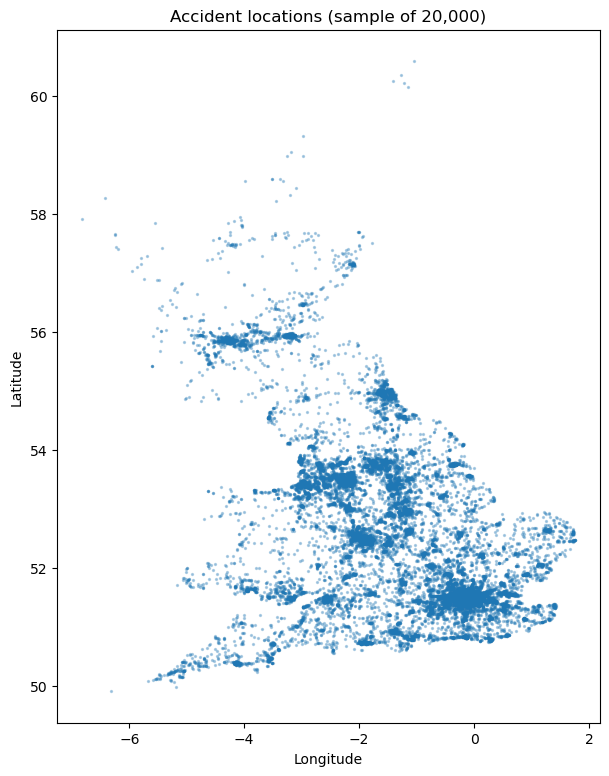

In [35]:
# 2 million points is too many to plot at once, so take a random sample
sample = accidents.sample(20000, random_state=42)

plt.figure(figsize=(7, 9))
plt.scatter(sample['Longitude'], sample['Latitude'], s=2, alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Accident locations (sample of 20,000)')
plt.show()

Even with no map behind it, the accidents **draw the shape of Great Britain on their own**.

That is a useful check that the latitude and longitude columns are correct — if they were
swapped or had the wrong sign, the shape would come out wrong. Only 175 rows are missing
coordinates.

The bright clumps are the big cities, with London obvious in the bottom right, and the faint
lines between them are motorways.

## Section 10 — What relates to severity?

This is the part I care about most.

As Finding 4 showed, counting accidents mostly tells me where people drive. So instead I work
out, **within each group, what percentage of its accidents were Fatal, Serious and Slight.**
Every group then adds up to 100%, so I can compare a common group against a rare one fairly.

Three pieces of pandas do the work, so to be clear about what each does:

- `.groupby('Speed_limit')` splits the data into separate piles, one pile per speed limit
- `.value_counts(normalize=True)` counts the severities inside each pile, and `normalize=True`
  turns those counts into proportions instead of raw numbers
- `.unstack()` moves the severity labels up into columns, so I end up with a table of one row
  per speed limit and one column per severity — which is the shape `.plot()` needs

### Speed limit

In [36]:
speed_severity = accidents.groupby('Speed_limit')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
speed_severity = speed_severity.loc[[20, 30, 40, 50, 60, 70]]
speed_severity * 100

Accident_Severity,Slight,Serious,Fatal
Speed_limit,,,
20.0,84.814709,14.664444,0.520847
30.0,86.564041,12.767824,0.668135
40.0,84.427140,14.103364,1.469496
50.0,82.489673,15.301026,2.209301
60.0,77.544894,19.301097,3.154009
70.0,85.269339,12.410984,2.319677


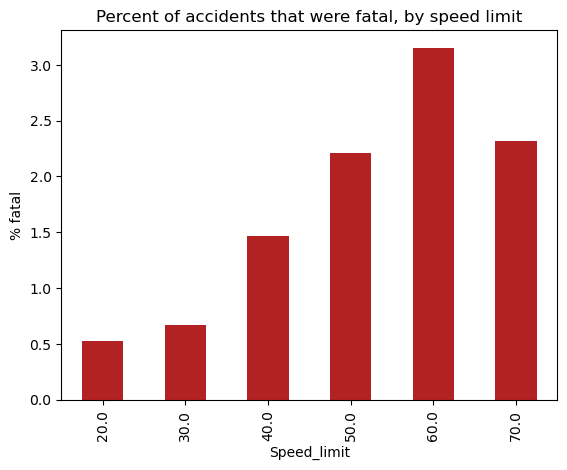

In [37]:
fatal_by_speed = speed_severity['Fatal'] * 100

fatal_by_speed.plot(kind='bar', color='firebrick')
plt.title('Percent of accidents that were fatal, by speed limit')
plt.ylabel('% fatal')
plt.show()

### Finding 5: 60 mph roads are worse than 70 mph roads

The fatal percentage climbs as the speed limit goes up — 0.52% at 20 mph, 0.67% at 30, 1.47%
at 40, 2.21% at 50, and **3.15% at 60 mph**. That is what I expected, because a faster crash
is harder to survive.

**Then it drops.** At 70 mph it falls to 2.32%, which is safer than 60 mph.

I think the reason is the kind of road each limit is used on:

- **70 mph** means a motorway or a good dual carriageway. The two directions are separated by
  a barrier, there are no pedestrians, and traffic joins using slip roads.
- **60 mph** is the normal limit for ordinary country roads. There is nothing between you and
  the traffic coming the other way, so two cars can meet head-on.

So what matters is the **design of the road**, not the number on the sign. That is a good
reason to give the model `Road_Type` and `Urban_or_Rural_Area` as well as `Speed_limit`.

I only plotted the six normal speed limits. The data also has 0, 10 and 15 mph limits, but
they only contain 1, 19 and 16 accidents, so their percentages jump around and don't mean
anything.

### Light conditions and urban vs rural

In [38]:
light_severity = accidents.groupby('Light_Conditions')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
light_severity * 100

Accident_Severity,Slight,Serious,Fatal
Light_Conditions,,,
Darkness - lighting unknown,85.378869,13.352762,1.268369
Darkness - lights lit,83.436597,15.215369,1.348034
Darkness - lights unlit,82.368870,15.725604,1.905526
Darkness - no lighting,75.730620,19.882106,4.387273
Daylight,85.755898,13.209493,1.034609


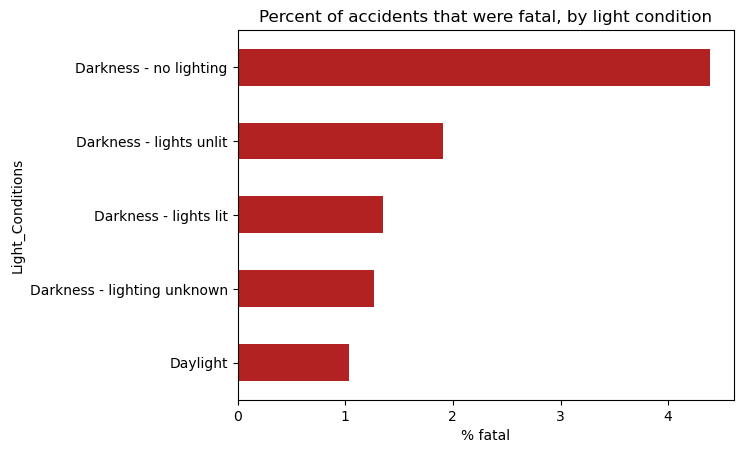

In [39]:
fatal_by_light = light_severity['Fatal'] * 100

fatal_by_light.sort_values().plot(kind='barh', color='firebrick')
plt.title('Percent of accidents that were fatal, by light condition')
plt.xlabel('% fatal')
plt.show()

In [40]:
area_severity = accidents.groupby('Urban_or_Rural_Area')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
area_severity * 100

Accident_Severity,Slight,Serious,Fatal
Urban_or_Rural_Area,,,
Rural,81.148578,16.504566,2.346856
Unallocated,85.000000,15.000000,NaN
Urban,86.685941,12.606223,0.707837


### Finding 6: dark roads with no street lighting are the most dangerous

- Daylight — 1.03% fatal
- Darkness, street lights on — 1.35%
- Darkness, street lights off — 1.91%
- **Darkness, no street lighting at all — 4.39%**

A crash on an unlit road in the dark is **more than 4 times as likely to be fatal** as one in
daylight.

The comparison I trust most is lights on (1.35%) against no lighting at all (4.39%). Both of
those are darkness, so the only real difference between them is whether the road has lighting
— which makes it a fairer comparison than dark against daylight.

Rural areas point the same way: **2.35% fatal against 0.71% in urban areas**.

I don't think these are separate results. Country roads are the ones that tend to be unlit,
and they are also the ones with 60 mph limits and no barrier down the middle. So this finding
and Finding 6 are probably describing **the same roads** from different angles.

### Weather — the opposite of what I expected

In [41]:
weather_severity = accidents.groupby('Weather_Conditions')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
weather_severity * 100

Accident_Severity,Slight,Serious,Fatal
Weather_Conditions,,,
Fine + high winds,82.933065,15.203750,1.863186
Fine no high winds,84.287008,14.382703,1.330289
Fog or mist,83.005060,14.844597,2.150343
Other,87.623347,11.473811,0.902842
Raining + high winds,84.758141,13.830575,1.411283
Raining no high winds,86.378776,12.559710,1.061513
Snowing + high winds,87.535183,11.861681,0.603136
Snowing no high winds,89.108837,10.069470,0.821693


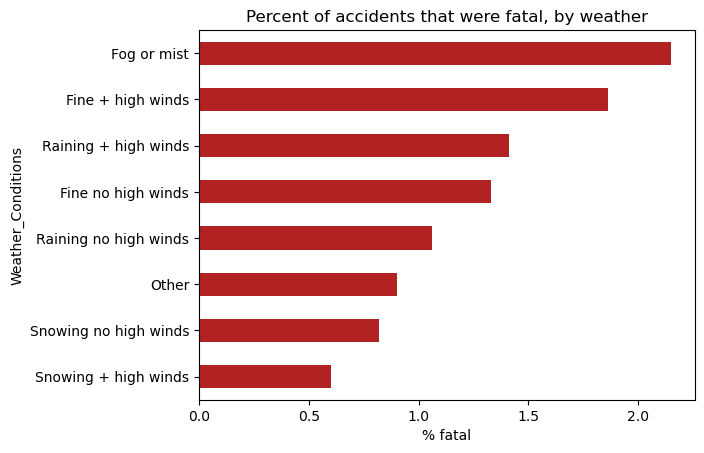

In [42]:
fatal_by_weather = weather_severity['Fatal'] * 100

fatal_by_weather.sort_values().plot(kind='barh', color='firebrick')
plt.title('Percent of accidents that were fatal, by weather')
plt.xlabel('% fatal')
plt.show()

### Finding 7: crashes in bad weather are less likely to be fatal

This was the biggest surprise, and it is the opposite of what I expected:

- Fog or mist — 2.15% fatal
- Fine + high winds — 1.86%
- Raining + high winds — 1.41%
- **Fine, no high winds — 1.33%**
- Raining, no high winds — 1.06%
- **Snowing, no high winds — 0.82%**

Crashes in snow are the *least* likely to be fatal, and rain is below fine weather too.

I don't think this means snow is safe to drive in. My best explanation is that **people drive
more slowly when the weather is obviously bad.** A slower crash is easier to survive, so bad
weather probably causes more crashes but less severe ones.

Fog fits that idea, because it is the worst one at 2.15%. Fog is harder to judge from inside a
warm car than snow is, so drivers may not slow down as much for it.

One more thing worth saying: this dataset only contains **crashes that happened**. There is no
record of the journeys where nothing went wrong. So I can't say how *likely* a crash is in each
kind of weather — only how bad it was once it happened.

**I would be careful putting this on the dashboard.** A chart that looks like it says "snow is
safer than sunshine" would mislead anyone who wasn't given this explanation.

### Road type

In [43]:
road_severity = accidents.groupby('Road_Type')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
road_severity * 100

Accident_Severity,Slight,Serious,Fatal
Road_Type,,,
Dual carriageway,85.880023,12.370842,1.749136
One way street,86.326229,13.003375,0.670396
Roundabout,90.410518,9.281630,0.307852
Single carriageway,83.831539,14.853896,1.314565
Slip road,89.934131,9.295853,0.770016


Roundabouts are the safest road type at 0.31% fatal, and dual carriageways the worst at 1.75%,
with single carriageways close behind at 1.31%.

Roundabouts make everyone slow down, and they turn crossing traffic into traffic all going the
same way round, which removes the head-on and right-angle crashes.

## Section 11 — The vehicle file

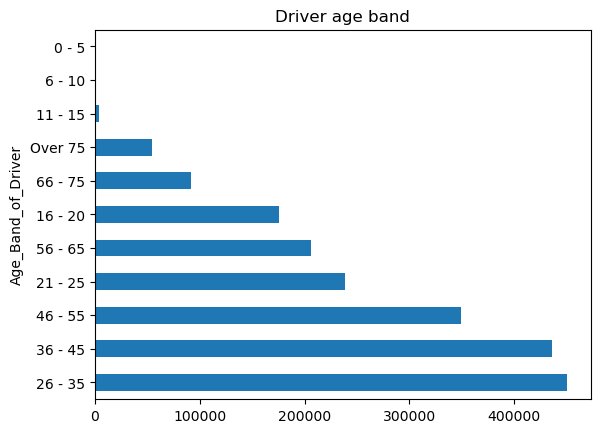

In [44]:
vehicles['Age_Band_of_Driver'].value_counts().plot(kind='barh')
plt.title('Driver age band')
plt.show()

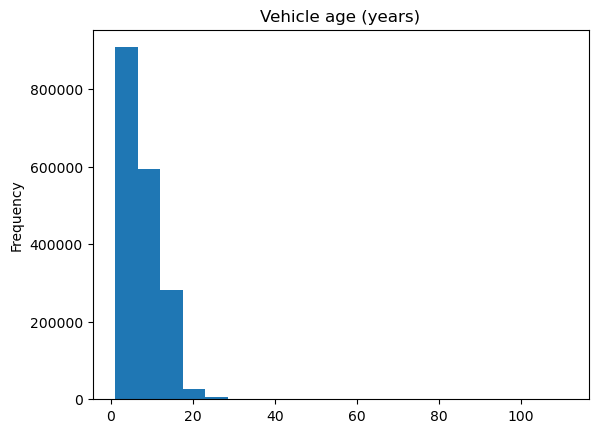

In [45]:
vehicles['Age_of_Vehicle'].plot(kind='hist', bins=20)
plt.title('Vehicle age (years)')
plt.show()

**Driver age.** The 26–35 band is biggest (450,531), then 36–45. Like the charts in Section 7
this mostly follows how many people of each age drive, so on its own it doesn't tell me who is
a riskier driver.

It did show a data quality problem though. There are 125 drivers in the 0–5 band, 884 in 6–10
and 3,655 in 11–15, and everyone in those bands is below the UK minimum driving age of 17.
They are probably cyclists, because `Age_Band_of_Driver` gets filled in for the person in
charge of *any* vehicle, and a pedal cycle counts as one. I would want to check that against
`Vehicle_Type` before using this column.

**Vehicle age.** Most vehicles are fairly new, with a middle value of 7 years. The long tail
out to 111 years is the impossible data I found in Finding 2.

To compare anything from the vehicle file against severity, the two tables have to be joined
first. `.merge()` matches rows using `Accident_Index`, and `how='inner'` keeps only the rows
that exist in both — which drops the 2004 rows I found in Section 5.

In [46]:
vehicles_with_severity = vehicles.merge(accidents[['Accident_Index', 'Accident_Severity']], on='Accident_Index', how='inner')

print('Vehicle rows before the join:', len(vehicles))
print('Vehicle rows after the join: ', len(vehicles_with_severity))

Vehicle rows before the join: 2177205
Vehicle rows after the join:  2058408


In [47]:
manoeuvre_severity = vehicles_with_severity.groupby('Vehicle_Manoeuvre')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
manoeuvre_severity = manoeuvre_severity.sort_values('Fatal')
manoeuvre_severity * 100

Accident_Severity,Slight,Serious,Fatal
Vehicle_Manoeuvre,,,
Waiting to turn left,94.269538,5.541735,0.188728
Waiting to go - held up,94.698538,5.030770,0.270693
Slowing or stopping,93.226181,6.457144,0.316675
Waiting to turn right,91.143976,8.380455,0.475569
Moving off,89.455591,10.036949,0.507460
Turning left,88.640175,10.819309,0.540516
Overtaking static vehicle - offside,82.822779,16.462849,0.714372
Turning right,85.302732,13.975828,0.721440
Reversing,87.665865,11.543486,0.790650


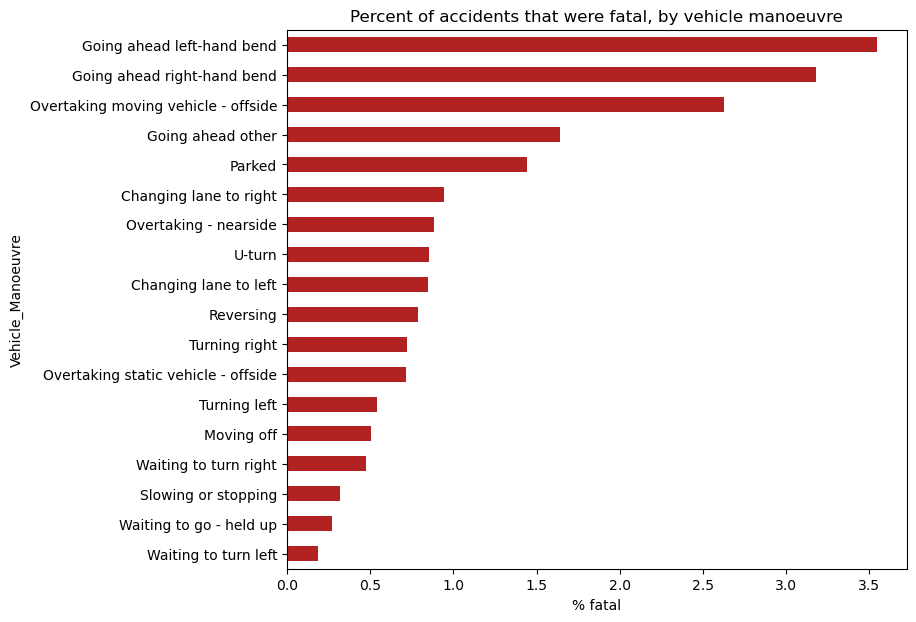

In [48]:
fatal_by_manoeuvre = manoeuvre_severity['Fatal'] * 100

fatal_by_manoeuvre.plot(kind='barh', color='firebrick', figsize=(8, 7))
plt.title('Percent of accidents that were fatal, by vehicle manoeuvre')
plt.xlabel('% fatal')
plt.show()

The join dropped exactly 118,797 rows, the same number I predicted in Section 5. That is a good
sign — the merge did what I expected and didn't quietly lose anything else.

The most fatal manoeuvres are **going ahead on a bend** (3.55% on a left-hand bend, 3.18% on a
right-hand bend) and **overtaking** at 2.63%. Bends and overtaking are both things you mostly
do on country roads, so this fits Findings 5 and 6.

The safest are the slow ones: waiting to turn left (0.19%), waiting while held up (0.27%) and
slowing or stopping (0.32%).

`Parked` is higher than I expected at 1.44%. A parked car isn't doing anything, so I think this
is really telling me something about the *other* vehicle — but I am not certain about that one.

### Vehicle make

`Vehicle_Manoeuvre` told me what the vehicle was doing. The `make` column tells me what badge
was on the front, which is the question people usually want answered: are some brands involved
in worse crashes than others?

`make` is filled in for 94.9% of rows and has 535 distinct values, so I keep only the makes with
at least 10,000 rows in the joined table. First though, a plain count of vehicle types. It turns
out to be the thing I need in order to read the brand chart properly, and one of its entries is
odd enough to be worth chasing afterwards.


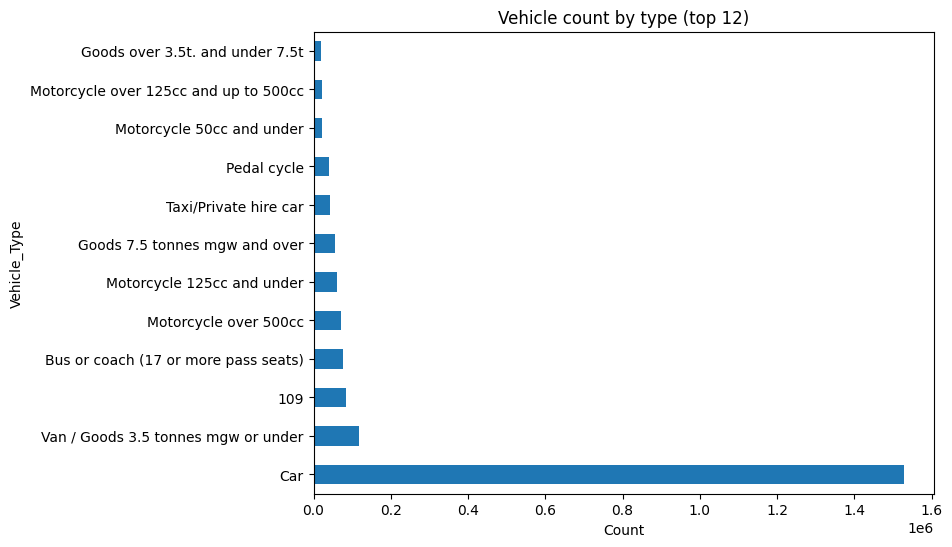

In [49]:
vehicles['Vehicle_Type'].value_counts().head(12).plot(kind='barh', figsize=(8, 6))
plt.title('Vehicle count by type (top 12)')
plt.xlabel('Count')
plt.show()


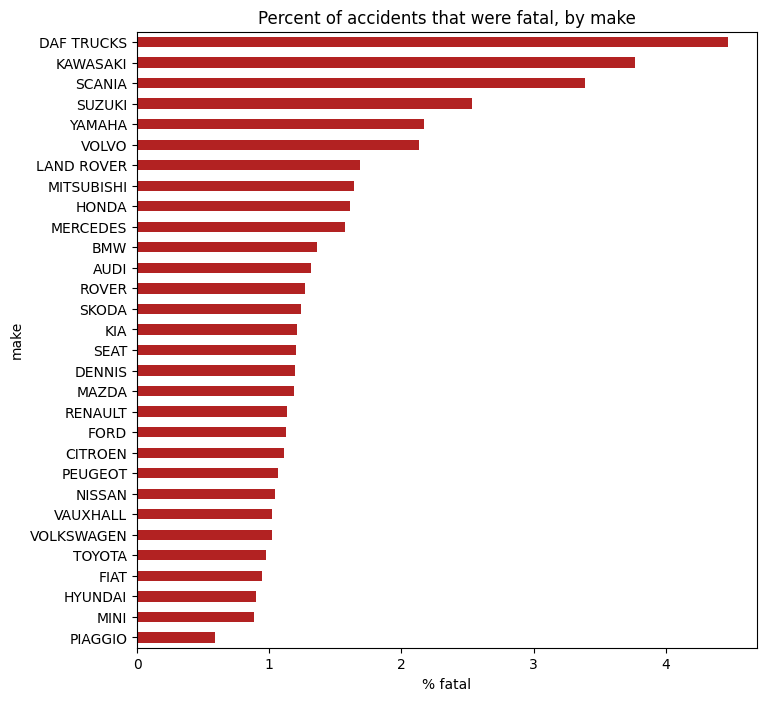

In [54]:
make_counts = vehicles_with_severity['make'].value_counts()
common_makes = make_counts[make_counts >= 10000].index

make_severity = vehicles_with_severity.groupby('make')['Accident_Severity'].value_counts(normalize=True).unstack()
fatal_by_make = (make_severity['Fatal'] * 100).loc[common_makes].sort_values()

fatal_by_make.plot(kind='barh', color='firebrick', figsize=(8, 8))
plt.title('Percent of accidents that were fatal, by make')
plt.xlabel('% fatal')
plt.show()


In [55]:
# The four makes at the top of that chart - what are they actually selling?
for name in ['DAF TRUCKS', 'KAWASAKI', 'SCANIA', 'SUZUKI', 'VOLVO']:
    mix = vehicles_with_severity.loc[vehicles_with_severity['make'] == name, 'Vehicle_Type']
    top3 = (mix.value_counts(normalize=True) * 100).head(3)
    print(name.ljust(11), ' | '.join(f'{k[:32]} {v:.0f}%' for k, v in top3.items()))


DAF TRUCKS  Goods 7.5 tonnes mgw and over 64% | Goods over 3.5t. and under 7.5t 18% | Van / Goods 3.5 tonnes mgw or un 6%
KAWASAKI    Motorcycle over 500cc 74% | Motorcycle over 125cc and up to  17% | Motorcycle 125cc and under 4%
SCANIA      Goods 7.5 tonnes mgw and over 49% | Bus or coach (17 or more pass se 40% | Goods over 3.5t. and under 7.5t 4%
SUZUKI      Car 43% | Motorcycle over 500cc 39% | Motorcycle over 125cc and up to  8%
VOLVO       Car 43% | Bus or coach (17 or more pass se 37% | Goods 7.5 tonnes mgw and over 16%


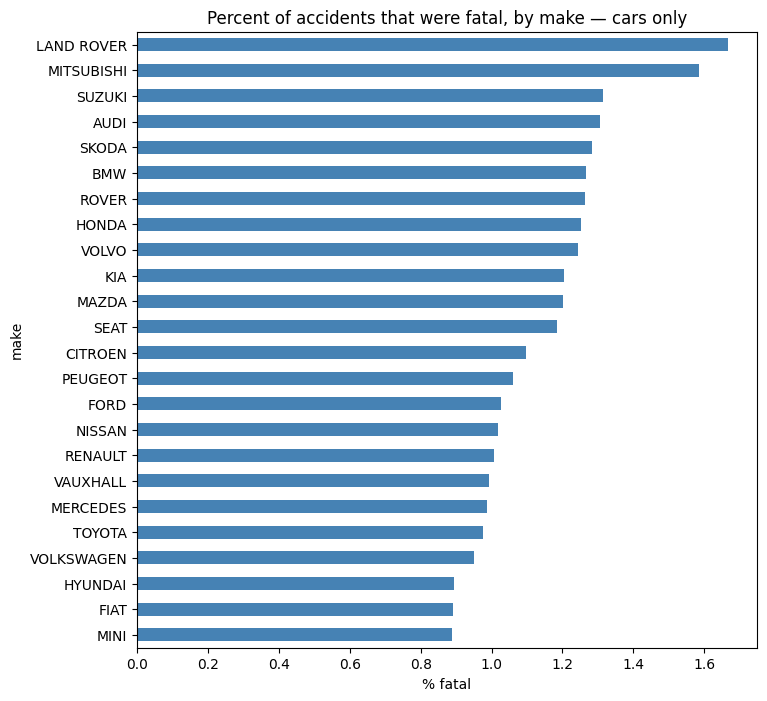

In [56]:
# Same chart, but comparing cars against cars only
cars = vehicles_with_severity[vehicles_with_severity['Vehicle_Type'] == 'Car']

car_make_counts = cars['make'].value_counts()
common_car_makes = car_make_counts[car_make_counts >= 10000].index

car_make_severity = cars.groupby('make')['Accident_Severity'].value_counts(normalize=True).unstack()
fatal_by_car_make = (car_make_severity['Fatal'] * 100).loc[common_car_makes].sort_values()

fatal_by_car_make.plot(kind='barh', color='steelblue', figsize=(8, 8))
plt.title('Percent of accidents that were fatal, by make — cars only')
plt.xlabel('% fatal')
plt.show()


### Finding 8: the brand ranking is mostly measuring what each brand builds

The first chart looks dramatic. **DAF Trucks is 4.47% fatal and Piaggio is 0.59%** — a
seven-and-a-half-fold spread between brands, which would be a striking thing to put on a
dashboard.

It is also almost entirely an illusion, and the top of the list gives it away. DAF builds
lorries, Scania builds lorries and coaches, and Kawasaki builds big motorcycles. These are not dangerous *brands*, they are
brands that happen to make the vehicle types Finding 4's warning applies to.

**Suzuki is the clearest tell.** It sits at 2.53% fatal, more than double Ford — but the mix
printout shows Suzuki is only 43% cars and 39% motorcycles over 500cc. Volvo does the same
thing from a different direction: 43% cars, 37% buses and 16% heavy goods. The badge is hiding
three completely different vehicles behind one label.

So I redrew it comparing **cars against cars**, which is the second chart. The spread collapses
from 7.6x down to **1.9x**. Suzuki falls from 2.53% to 1.31%, and Volvo from 2.13% to 1.24%.
Almost everything the first chart appeared to show about brands was vehicle type wearing a
badge.

What survives the control is small but not nothing, and it points somewhere familiar:

- **Land Rover 1.67% and Mitsubishi 1.59%** at the top — the 4x4s.
- **Mini 0.89%, Fiat 0.89% and Hyundai 0.89%** at the bottom — small city cars.
- Ford, Vauxhall, Renault and Nissan all sit within a whisker of the 1.08% car average.

That ordering looks much more like *where a car gets driven* than how safe it is. Big 4x4s do
disproportionately many miles on exactly the fast rural roads Findings 5 and 6 flagged, and
superminis do their miles in town. I think this is Finding 5 and Finding 6 showing up a third
time rather than anything about the vehicles themselves.

**This is not a safety rating and should not be presented as one.** Three reasons: a row is a
vehicle *involved in* a crash rather than a casualty, so a high number can mean the brand killed
someone in the other car; I have no idea how many miles any brand covers, which is the same
exposure problem as Finding 4; and I cannot separate the car from the person who chose it or the
roads they drive it on. `make` is also missing for 5.1% of rows overall and about a quarter of
2015, so the recent years are thinner than the rest.

For the model, the practical conclusion is that **`make` should stay out**, or go in only after
`Vehicle_Type` is already there. On its own it looks like a strong predictor; next to the column
it is standing in for, it has very little left to add.


In [51]:
# 109 was the third most common vehicle type, but not one of its rows survived the join.
# Which years do the numeric codes appear in?
numeric_codes = ['109', '106', '108']
print(vehicles[vehicles['Vehicle_Type'].isin(numeric_codes)].groupby(['Vehicle_Type', 'Year']).size())

print()
print('Cars recorded in 2004:', (vehicles.loc[vehicles['Year'] == 2004, 'Vehicle_Type'] == 'Car').sum())
print('Share of 2004 rows coded 109:      {:.1%}'.format(
    (vehicles.loc[vehicles['Year'] == 2004, 'Vehicle_Type'] == '109').mean()))
print('Share of all other years that are Car: {:.1%}'.format(
    (vehicles.loc[vehicles['Year'] != 2004, 'Vehicle_Type'] == 'Car').mean()))


Vehicle_Type  Year
106           2004     7568
108           2004     1334
109           2004    82920
dtype: int64

Cars recorded in 2004: 0
Share of 2004 rows coded 109:      69.8%
Share of all other years that are Car: 74.3%


### Finding 9: the mystery code `109` is just "Car" under 2004's old coding

This one fell out of the join. In Finding 2 I flagged `109` as an unlabelled code covering
82,920 rows and had no idea what it was. It turns out all three numeric codes — `109`, `106`
and `108` — appear in **2004 and in no other year**, and 2004 is exactly the year the accident
file doesn't cover. That is why every one of those rows disappeared when I merged.

The clincher is what 2004 is missing. There is **not a single row labelled `Car` in 2004**,
even though cars are 74.3% of every other year. And `109` accounts for 69.8% of 2004's rows.

A category that makes up 70% of vehicles in every year except one, and a numeric code that
makes up 70% of the one year where that category is absent, is not a coincidence. **`109` is
`Car`**, recorded under the coding scheme that was in use before the labels were switched to
text in 2005.

So the answer to the question I raised earlier is that 2004 is a different vintage of the data
that got appended to the same file without being translated. It doesn't change any of my
results, because all of 2004 drops out of the join anyway — but it does mean the right fix is
to drop 2004 deliberately rather than let it fall out by accident, and nobody should treat
`109` as a real vehicle category.


---
## Section 12 — Accidents over time

Every chart so far has flattened all thirteen years into one number. Since `Year` is right
there in the accident file, the obvious question is whether any of this is moving.


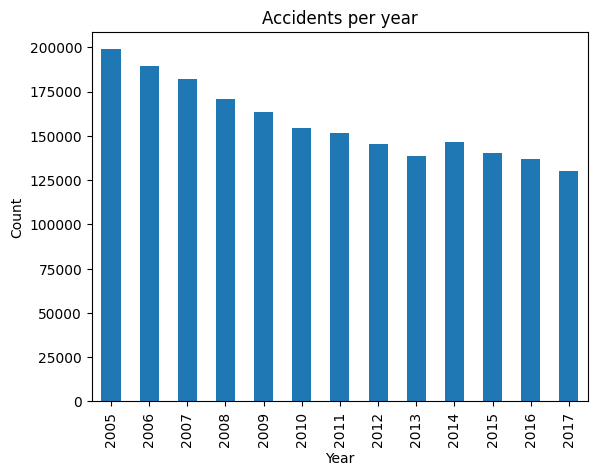

In [52]:
accidents['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents per year')
plt.ylabel('Count')
plt.show()


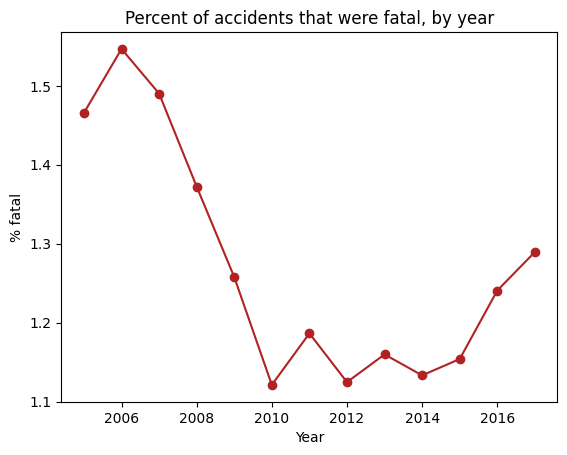

In [53]:
year_severity = accidents.groupby('Year')['Accident_Severity'].value_counts(normalize=True).unstack()
fatal_by_year = year_severity['Fatal'] * 100

fatal_by_year.plot(kind='line', marker='o', color='firebrick')
plt.title('Percent of accidents that were fatal, by year')
plt.ylabel('% fatal')
plt.show()


### Finding 10: accidents fell by a third, but the fatal share stopped improving in 2010

The count chart falls steadily and hard. 2005 had 198,735 accidents and 2017 had 129,982 — a
**34.6% drop** across thirteen years. The only year that goes up at all is 2014.

The second chart is the one I did not expect. The fatal percentage nudges up to a peak of 1.55%
in 2006, then falls steeply for four years to **1.12% in 2010** — and there it stops, drifts
sideways, and climbs back to 1.29% by 2017. Nearly 40% of the improvement has been given
back.

Putting the two together is what makes it interesting. Accidents kept falling after 2010, but
the *fatal* count flattened out — 1,731 in 2010 against 1,676 in 2017, essentially unchanged
while total accidents fell by another 15%. So whatever drove the improvement up to 2010 was
taking crashes off the road across the board, and since then the ordinary crashes have carried
on falling while the deadly ones have not.

I can't tell from this data why. It could be genuinely worse outcomes, or it could be a
reporting change — if minor slight-injury crashes became less likely to be reported over time,
the fatal share would rise on its own without anything actually getting worse. Both would look
exactly like this chart.

The practical point for us is that **year is not a neutral column**. If we train on all
thirteen years pooled together, the model learns an average fatal rate that was never true in
any particular year, and it learns it mostly from the older years, which are the biggest. I'd
want us to decide deliberately whether `Year` goes into the model as a feature, and whether
the older years should be down-weighted or dropped.


---
## Section 13 — Summary of findings

### Findings

**1. A lot of the missing data was hidden as text.** Values like `'Data missing or out of range'`
and `'Not known'` are stored as ordinary text, so `.isnull()` never finds them. That is 45% of
`Journey_Purpose_of_Driver` and 37% of `Junction_Control`.

**2. Some values were impossible rather than missing.** Vehicle ages up to 111 years and engines
up to 96,000cc. Checking for blanks would never have caught these.

**3. Only 1.29% of accidents are fatal.** 84.73% are Slight and 13.99% Serious. A model that
always guessed "Slight" would be 84.7% accurate and never find a single fatal crash — so
accuracy is the wrong way to score it.

**4. Counting accidents shows where people drive, not what is dangerous.** 80% of accidents
happened in fine weather simply because that is when most driving happens. Everywhere after
this I use the percentage of each group that was fatal instead of the count.

**5. 60 mph roads are worse than 70 mph roads.** 3.15% fatal against 2.32%. 70 mph means
motorways with the two directions separated; 60 mph means country roads where cars can meet
head-on.

**6. Dark roads with no street lighting are the most dangerous.** 4.39% fatal against 1.03% in
daylight, and rural roads beat urban ones 2.35% to 0.71%. This is probably describing the same
roads as Finding 5.

**7. Crashes in bad weather are less likely to be fatal.** Snow is 0.82% against 1.33% in fine
weather. People drive slower when conditions are obviously bad, so the crashes are less severe.

**8. The brand ranking mostly measures what each brand builds.** DAF Trucks tops the list at
4.47% and Piaggio sits at the bottom on 0.59% — but those are a lorry maker and a scooter maker.
Comparing cars against cars shrinks the gap from 7.6x to 1.9x. This is not a safety rating.

**9. The mystery code `109` is "Car" under 2004's old coding.** The numeric codes appear only in
2004, the one year the accident file doesn't cover. 2004 has no rows labelled `Car` at all, and
`109` is 69.8% of that year. This closes the question I raised in Finding 2.

**10. Accidents fell 34.6%, but the fatal share stopped improving in 2010.** It went 1.55% in
2006, down to 1.12% in 2010, back up to 1.29% by 2017. Fatal crashes have been flat near 1,650
a year since 2011 while total accidents kept falling.

### Additional questions

Five things I could not settle on my own.

**1. Are the unlit roads, the rural roads and the 60 mph roads all the same roads?**
If they are, those three columns are largely repeating each other and the model may not need
all of them.

**2. Does the weather result hold on a single road type?**
People may simply avoid fast country roads when it snows, which would explain Finding 7 without
anyone driving more carefully.

**3. Is the missing data connected to severity?**
If the rows missing `Junction_Control` are more or less serious than the rest, then a value
being missing is itself information and we should not just fill it in.

**4. Are the under-17 drivers really cyclists?**
I assumed the 0–5, 6–10 and 11–15 age bands are cyclists without checking. Calling them "child
drivers" on a dashboard would be badly wrong if I am.

**5. Should we predict all three severity levels, or combine Fatal and Serious?**
1.29% may be too rare for a model to learn from. Combining them makes the small class bigger
but loses the difference between a fatal crash and a serious one.

One limitation we probably cannot fix: we have no record of how much traffic was on the road, so
we can only count accidents, not work out how likely one is.
